# Interaction Strength Analysis Results

Weeks 6-9 work investigating and quantifying interaction strength between channel pairs.

In [2]:
# Import dependencies
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd

# Setup image display function

def display_image(img_name: str):
    path = "../interaction_strength_figs/" + img_name
    im = mpimg.imread(path)
    plt.imshow(im)
    plt.axis("off")
    plt.show()

## Channel Spend Interactions

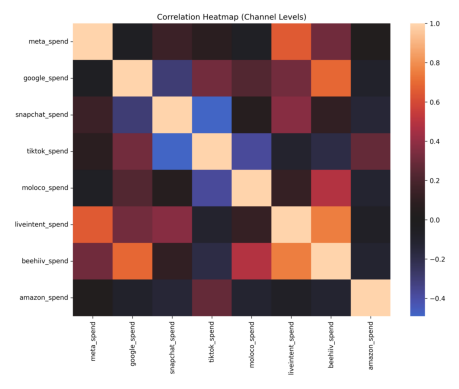

In [3]:
display_image("correlation_heatmap.png")

The channel-level correlation heatmap shows strong positive relationships between several marketing channels, particularly LiveIntent and Beehiiv (≈0.85) and Google and Beehiiv (≈0.75), suggesting these channels tend to increase or decrease together. Meta and LiveIntent also exhibit a relatively strong correlation (around 0.65–0.70), indicating coordinated movement in spend. In contrast, some pairs show weak or negative relationships, such as Snapchat and TikTok (≈−0.45) and TikTok and Moloco (≈−0.30), suggesting these channels may operate more independently or shift budgets in opposite directions. Overall, the heatmap highlights clusters of channels—especially Beehiiv, LiveIntent, and Google—that tend to move together in the dataset.

## Investigating Lagged Correlation

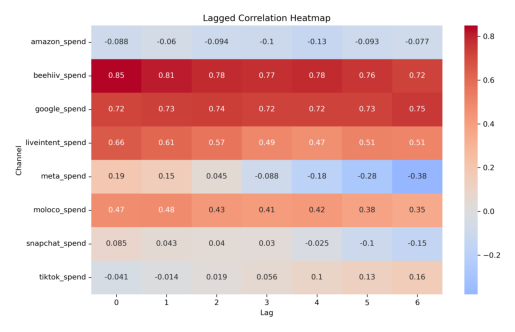

In [4]:
display_image("lagged_heatmap.png")

The lagged correlation heatmap shows that Beehiiv spend has the strongest correlations with the target across time, with values decreasing gradually from 0.85 at lag 0 to about 0.72 by lag 6, indicating a persistent relationship over time. Google spend also maintains consistently strong correlations, ranging from roughly 0.72–0.75 across all lags, while LiveIntent shows moderate correlations that decline from 0.66 at lag 0 to around 0.47–0.51 by later lags. In contrast, Meta’s correlation becomes increasingly negative over time (from about 0.19 at lag 0 to −0.38 at lag 6), and channels like Snapchat and TikTok show weak correlations overall (generally between −0.15 and 0.16).

Channels such as Meta, Snapchat, and TikTok show weak or declining correlations, which suggests their current spending patterns may not be strongly aligned with the target outcome being measured. For Meta in particular, the increasingly negative correlations could indicate issues such as targeting inefficiencies, measurement misalignment, or budget being deployed in response to demand rather than generating it. 

## Modeling and Quantifying Interactions

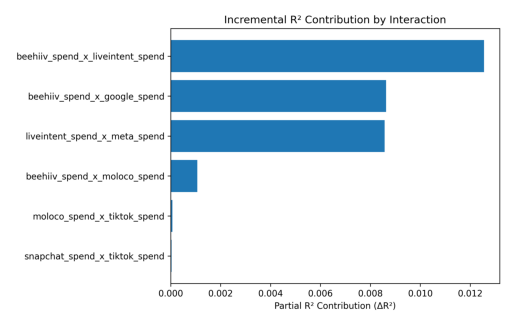

In [5]:
display_image("partial_r2_interactions.png")

The interaction model shows that the strongest cross-channel synergy occurs between Beehiiv and LiveIntent, which adds about ΔR² ≈ 0.0125 of additional explanatory power to the model. Other notable interactions include Beehiiv × Google (ΔR² ≈ 0.0088) and LiveIntent × Meta (ΔR² ≈ 0.0087), both contributing meaningful but smaller improvements in model fit. In contrast, interactions such as Beehiiv × Moloco (~0.001) and those involving TikTok or Snapchat (≈0) add very little predictive value. Overall, only a few channel combinations meaningfully improve the model, with the strongest gains concentrated around interactions involving Beehiiv.

## Granger Causality Testing

In [6]:
granger_casuality_summary = pd.read_csv("../interaction_strength_figs/granger_summary_with_fdr.csv")
granger_casuality_summary

,target,driver,best_lag,min_pvalue,fdr_qvalue,sig_p05,sig_fdr_05
0,amazon_spend,meta_spend,3,8.202508e-09,4.593404e-07,True,True
1,google_spend,liveintent_spend,3,5.795737e-04,1.622806e-02,True,True
2,beehiiv_spend,moloco_spend,2,5.869067e-03,1.095559e-01,True,False
3,meta_spend,amazon_spend,1,1.301752e-02,1.578698e-01,True,False
4,snapchat_spend,moloco_spend,1,1.409552e-02,1.578698e-01,True,False
5,liveintent_spend,beehiiv_spend,3,2.792908e-02,2.428559e-01,True,False
6,amazon_spend,tiktok_spend,2,3.177716e-02,2.428559e-01,True,False
7,tiktok_spend,amazon_spend,3,3.899923e-02,2.428559e-01,True,False
8,moloco_spend,liveintent_spend,3,3.903041e-02,2.428559e-01,True,False
9,google_spend,beehiiv_spend,3,5.976300e-02,3.322624e-01,False,False


After correcting for multiple hypothesis testing using FDR, the results suggest that there are only two interactions remain siginficant: Meta spend predicting Amazon spend at lag 3, and LiveIntent spend predicting Google spend at lag 3. Several additional channel pairs were significant at the nominal 5% level, but these did not survive FDR correction and should be treated as exploratory rather than confirmatory. Overall, the results suggest a sparse lead-lag structure in channel spend, with only a small number of robust cross-channel predictive relationships.

Across the analyses, a consistent pattern emerges in which Beehiiv, LiveIntent, and Google appear to form the strongest cluster of related channels. The correlation heatmaps show high contemporaneous relationships—such as LiveIntent–Beehiiv (≈0.85) and Google–Beehiiv (≈0.75)—and these relationships remain strong across lags, with Beehiiv maintaining correlations from about 0.85 at lag 0 to ~0.72 by lag 6 and Google staying around 0.72–0.75 across all lags. The interaction model reinforces this pattern, with the largest incremental contribution coming from Beehiiv × LiveIntent (ΔR² ≈ 0.0125) and additional gains from Beehiiv × Google (ΔR² ≈ 0.0088) and LiveIntent × Meta (ΔR² ≈ 0.0087). However, the Granger causality results indicate that only two predictive relationships remain statistically robust after FDR correction—Meta → Amazon (lag 3) and LiveIntent → Google (lag 3)—suggesting that while several channels move together or interact in the model, only a small number exhibit strong lead–lag predictive effects.

### Interaction Modeling Results


In [7]:
import pandas as pd
from IPython.display import Image

interaction_results = pd.read_csv("../interaction_strength_figs/interaction_effects.csv")
partial_r2_results = pd.read_csv("../interaction_strength_figs/interaction_partial_r2.csv")

In [8]:
interaction_results

,interaction,coef,lower_95,upper_95,abs_coef
0,beehiiv_spend_x_google_spend,-736.994310,-1551.279013,77.290394,736.994310
1,beehiiv_spend_x_liveintent_spend,612.438783,51.385807,1173.491759,612.438783
2,liveintent_spend_x_meta_spend,-250.213180,-527.596817,27.170458,250.213180
3,beehiiv_spend_x_moloco_spend,-151.329039,-627.042228,324.384149,151.329039
4,moloco_spend_x_tiktok_spend,-57.337634,-761.515796,646.840527,57.337634
5,snapchat_spend_x_tiktok_spend,28.079755,-474.552185,530.711695,28.079755


In [9]:
partial_r2_results

,interaction,partial_r2
0,beehiiv_spend_x_liveintent_spend,0.012556
1,beehiiv_spend_x_google_spend,0.008632
2,liveintent_spend_x_meta_spend,0.008574
3,beehiiv_spend_x_moloco_spend,0.001066
4,moloco_spend_x_tiktok_spend,0.000070
5,snapchat_spend_x_tiktok_spend,0.000033


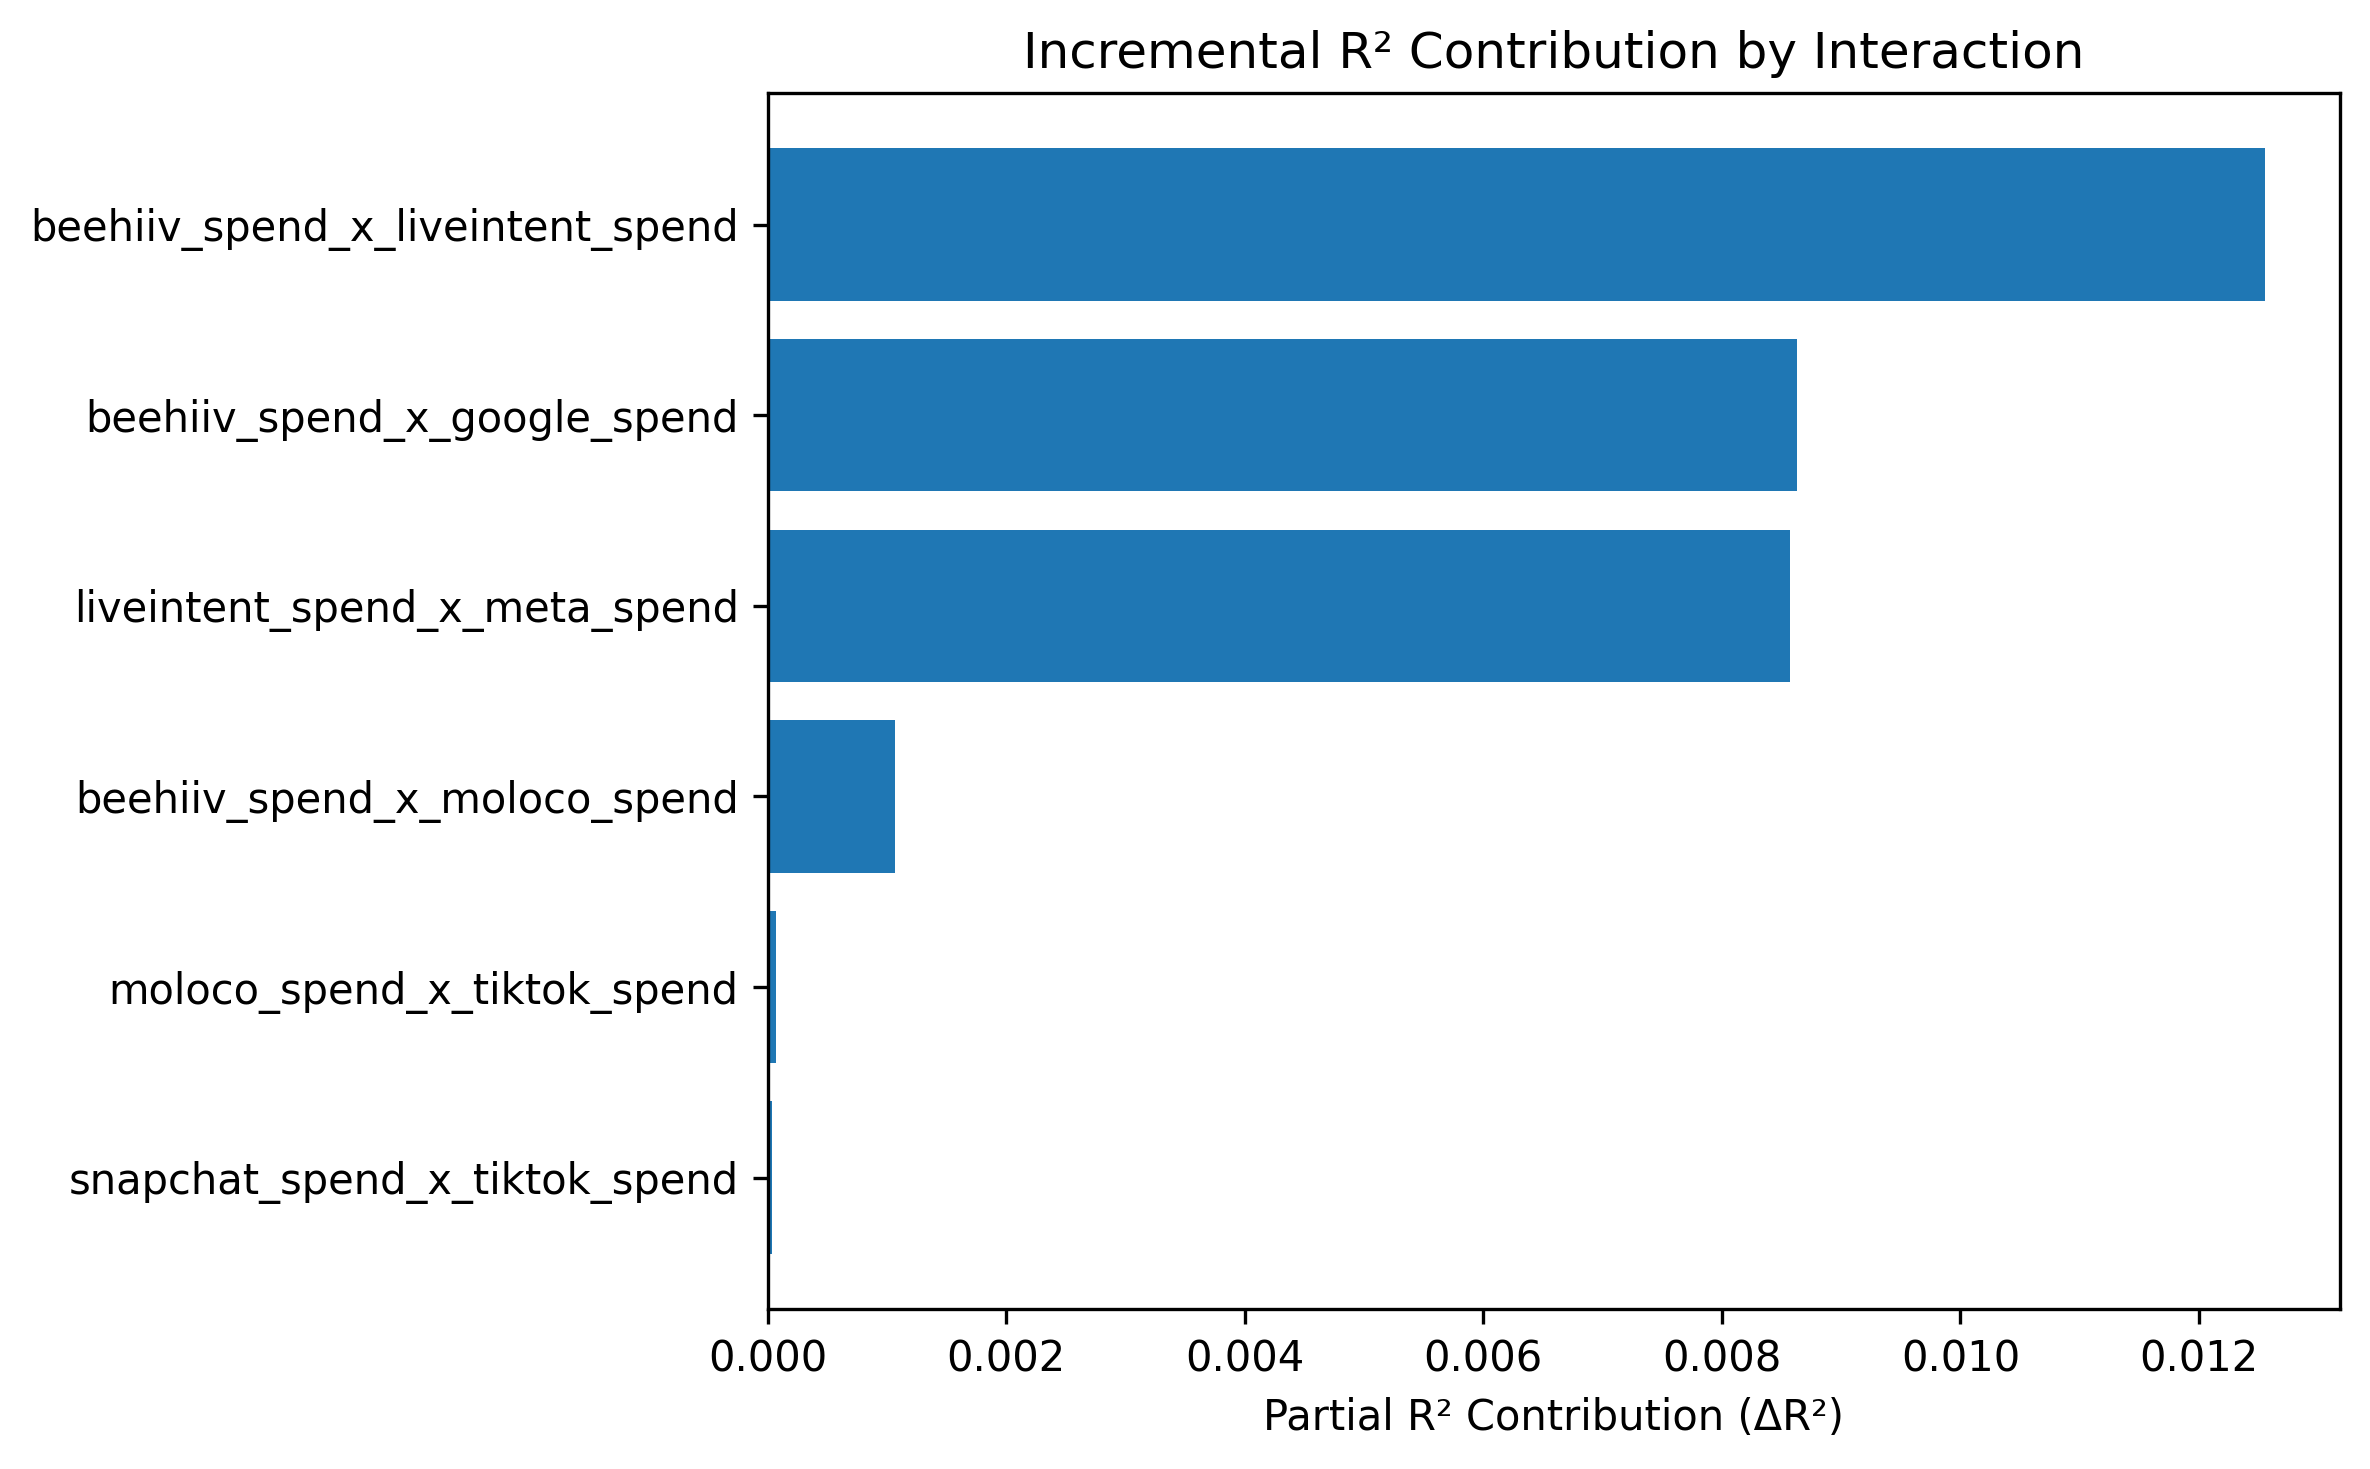

In [13]:

Image("../interaction_strength_figs/partial_r2_interactions.png", width=700)

### Interpretation of Results

After adding the interaction terms, the model achieved an R² of 0.845, meaning it explains about 84.5% of the variation in subscriptions. This is slightly better than the model without interactions, which suggests that some cross-channel effects may exist.

Looking at the interaction coefficients, the largest effects appear for Beehiiv × Google, Beehiiv × LiveIntent, and LiveIntent × Meta. However, when we check the 95% confidence intervals, only Beehiiv × LiveIntent does not include zero. This suggests there is clear positive synergy between these two channels, meaning they seem to work better together than individually.

The other interactions have larger uncertainty because their confidence intervals cross zero, so they should be interpreted as possible signals rather than strong conclusions.

We also calculated Partial R² to see how much each interaction improves the model. Beehiiv × LiveIntent contributes the most additional explanatory power, followed by Beehiiv × Google and LiveIntent × Meta, while the other interactions add very little to the model.

### Next Steps

As we've now established significant channel pairs in the data set, we can proceed to modeling them as interaction models within Merdian's MMMs. After coefficients are fit, we can utilize the granger causality test results to interpret channel spend/impression relationships and inform budget allocation recommendations.